# Data sanity checks

Checks on `data/processed/sharp_labeled.parquet` and `splits.csv` produced by `src/build_labels.py` and `src/make_splits.py`.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from build_labels import tai_to_utc, goes_class_to_flux, clean_flares

BLUE, ORANGE, INK, MUTED = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED,
                     "ytick.color": MUTED, "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.6})

df = pd.read_parquet(ROOT / "data/processed/sharp_labeled.parquet")
splits = pd.read_csv(ROOT / "data/processed/splits.csv")
print(len(df), "rows,", df.NOAA_AR.nunique(), "ARs, positive rate", f"{df.y.mean():.2%}")

187465 rows, 1197 ARs, positive rate 2.91%


## Rows per AR

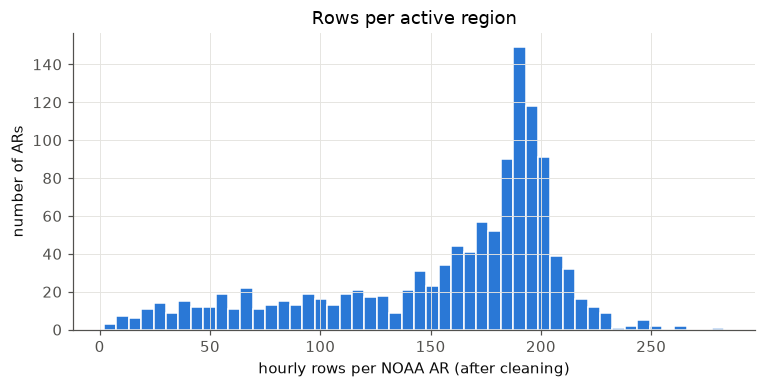

count    1197.0
mean      156.6
std        54.8
min         2.0
25%       126.0
50%       179.0
75%       195.0
max       283.0
ARs with < 24 rows: 25


In [2]:
rows_per_ar = df.groupby("NOAA_AR").size()
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(rows_per_ar, bins=50, color=BLUE, edgecolor="white", linewidth=1)
ax.set(xlabel="hourly rows per NOAA AR (after cleaning)", ylabel="number of ARs",
       title="Rows per active region")
plt.show()
print(rows_per_ar.describe().round(1).to_string())
print("ARs with < 24 rows:", (rows_per_ar < 24).sum())

## Rows and positives over time

Positives should follow solar cycle 24 (peak ~2014).

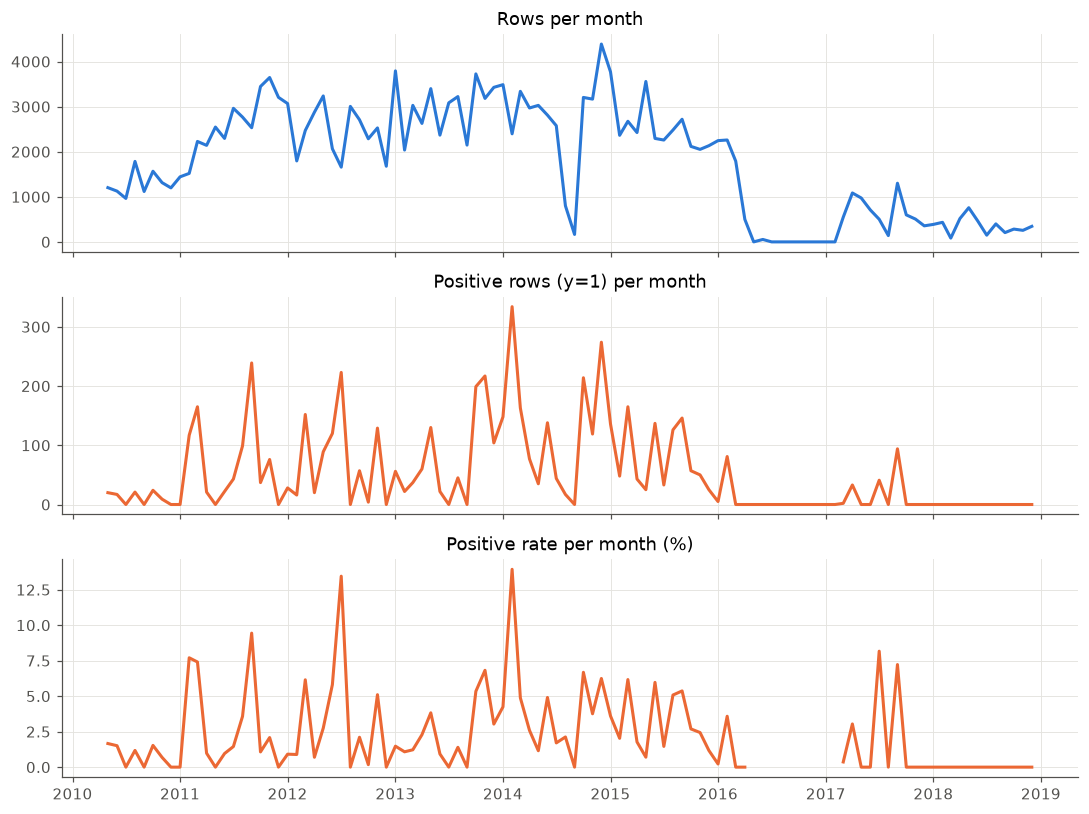

,rows,positives,pos_pct
T_REC,,,
2010,10275,91,0.89
2011,30735,819,2.66
2012,29378,838,2.85
2013,36043,892,2.47
2014,32334,1563,4.83
2015,30852,991,3.21
2016,6850,86,1.26
2017,6719,170,2.53
2018,4279,0,0.00


In [3]:
monthly = df.set_index("T_REC").resample("MS").agg({"y": ["size", "sum", "mean"], "NOAA_AR": "nunique"})
monthly.columns = ["rows", "positives", "pos_rate", "ARs"]
fig, axes = plt.subplots(3, 1, figsize=(10, 7.5), sharex=True)
axes[0].plot(monthly.index, monthly.rows, color=BLUE, lw=2); axes[0].set_title("Rows per month")
axes[1].plot(monthly.index, monthly.positives, color=ORANGE, lw=2); axes[1].set_title("Positive rows (y=1) per month")
axes[2].plot(monthly.index, 100 * monthly.pos_rate, color=ORANGE, lw=2); axes[2].set_title("Positive rate per month (%)")
fig.tight_layout(); plt.show()
yearly = df.groupby(df.T_REC.dt.year).agg(rows=("y", "size"), positives=("y", "sum"), pos_pct=("y", "mean"))
yearly["pos_pct"] = (100 * yearly.pos_pct).round(2)
yearly

## Spot-check known big flares

For each AR, take its largest GOES flare from the flare list and confirm every cleaned row with T_REC (UTC) in [peak − 24h, peak) has y = 1. Rows may be absent if the AR was beyond ±60° or had QUALITY ≠ 0.

In [4]:
flares = clean_flares(pd.read_parquet(ROOT / "data/raw/goes_flares_raw.parquet"))
df["t_utc"] = tai_to_utc(df["T_REC"])
for ar in [11158, 11429, 12673]:
    f = flares[flares.ar == ar].sort_values("flux", ascending=False)
    print(f"\n=== AR {ar}: top flares ===")
    print(f.head(4)[["peak", "fl_goescls"]].to_string(index=False))
    for _, fl in f[f.flux >= 1e-4].iterrows():
        w = df[(df.NOAA_AR == ar) & (df.t_utc >= fl.peak - pd.Timedelta("24h")) & (df.t_utc < fl.peak)]
        lon = f"LON_FWT {w.LON_FWT.min():.0f}..{w.LON_FWT.max():.0f}" if len(w) else "no rows (off-disk/limb or cleaned out)"
        status = "OK" if len(w) and (w.y == 1).all() else ("NO ROWS" if not len(w) else "FAIL")
        print(f"  {fl.fl_goescls} peak {fl.peak}: {len(w)} rows in prior 24h, y=1 in {int(w.y.sum())} -> {status}  [{lon}]")


raw flare rows: 14741, after dedup across yearly queries: 14734
  drop unparseable class:             0
  drop missing/zero AR number:     2521 (of which >=M1.0: 32)
  usable flares: 12213 (>=M1.0: 772)

=== AR 11158: top flares ===
               peak fl_goescls
2011-02-15 01:56:00       X2.2
2011-02-13 17:38:00       M6.6
2011-02-18 10:11:00       M6.6
2011-02-14 17:26:00       M2.2
  X2.2 peak 2011-02-15 01:56:00: 22 rows in prior 24h, y=1 in 22 -> OK  [LON_FWT -0..12]

=== AR 11429: top flares ===
               peak fl_goescls
2012-03-07 00:24:00       X5.4
2012-03-05 04:09:00       X1.1
2012-03-10 17:44:00       M8.4
2012-03-13 17:41:00       M7.9
  X5.4 peak 2012-03-07 00:24:00: 20 rows in prior 24h, y=1 in 20 -> OK  [LON_FWT -39..-26]
  X1.1 peak 2012-03-05 04:09:00: 13 rows in prior 24h, y=1 in 13 -> OK  [LON_FWT -59..-50]

=== AR 12673: top flares ===
               peak fl_goescls
2017-09-06 12:02:00       X9.3
2017-09-10 16:06:00       X8.2
2017-09-06 09:10:00       X2.2
2

## Correlation of phase-1 features

Spearman (rank) correlation, since the extensive parameters span orders of magnitude.

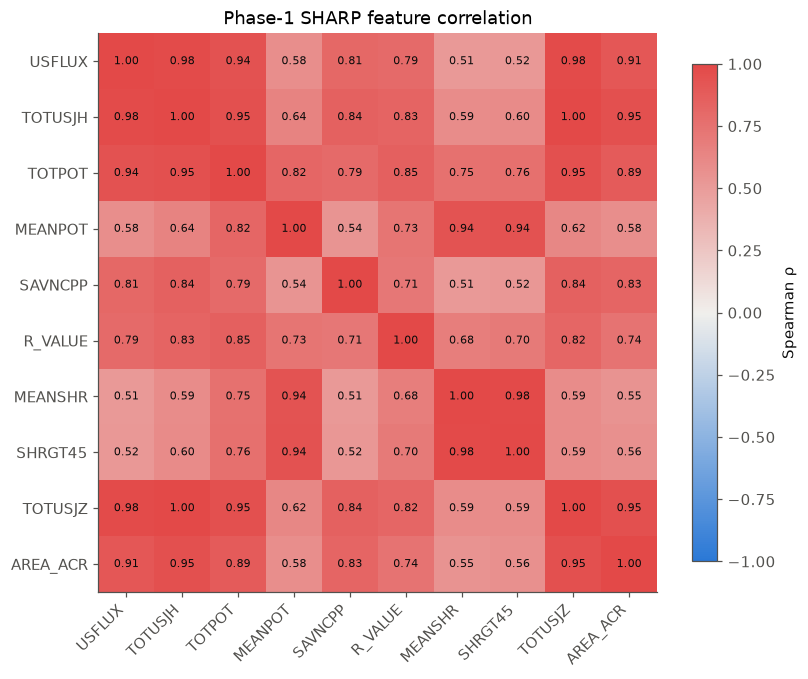

In [5]:
PHASE1 = ["USFLUX", "TOTUSJH", "TOTPOT", "MEANPOT", "SAVNCPP", "R_VALUE", "MEANSHR", "SHRGT45", "TOTUSJZ", "AREA_ACR"]
corr = df[PHASE1].corr(method="spearman")
cmap = LinearSegmentedColormap.from_list("div", ["#2a78d6", "#f0efec", "#e34948"])
fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(PHASE1)), PHASE1, rotation=45, ha="right"); ax.set_yticks(range(len(PHASE1)), PHASE1)
ax.grid(False)
for i in range(len(PHASE1)):
    for j in range(len(PHASE1)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7.5, color=INK)
fig.colorbar(im, ax=ax, shrink=0.8, label="Spearman ρ")
ax.set_title("Phase-1 SHARP feature correlation")
fig.tight_layout(); plt.show()

## Splits

In [6]:
m = df.merge(splits, on="NOAA_AR")
assert splits.groupby("NOAA_AR").split.nunique().max() == 1
m.groupby("split").agg(ARs=("NOAA_AR", "nunique"), rows=("y", "size"), pos_pct=("y", lambda s: round(100 * s.mean(), 2)))

,ARs,rows,pos_pct
split,,,
test,119,18466,1.98
train,958,150263,2.88
val,120,18736,4.06
